In [ ]:
!pip install seqeval

In [ ]:
import os
import numpy as np
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
import torch

from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

In [ ]:
MODEL_NAME = "roberta-base"
DATASET_NAME = "mnaguib/WikiNER"
DATASET_CONFIG = "en"
OUTPUT_DIR = "./roberta_ner_output"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
SEED = 42

LABEL_LIST = ["O", "LOC", "PER", "MISC", "ORG"]
LABEL2ID = {label: i for i, label in enumerate(LABEL_LIST)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}
NUM_LABELS = len(LABEL_LIST)

In [ ]:
def load_wikiner():
    print("Loading WikiNER dataset....")
    dataset = load_dataset(DATASET_NAME, DATASET_CONFIG)
    return dataset

dataset = load_wikiner()

Loading WikiNER dataset....


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, add_prefix_space=True)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["words"],
        truncation=True,
        max_length=MAX_LENGTH,
        is_split_into_words=True,
        padding=False,
    )

    all_labels = []
    for i, labels in enumerate(examples["ner_tags"]): #tambahan
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_id = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != previous_word_id:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)
            previous_word_id = word_id

        all_labels.append(label_ids)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

print("Tokenizing dataset...")
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names,
)
print("Tokenization complete.")

Tokenizing dataset...


Map:   0%|          | 0/14398 [00:00<?, ? examples/s]

Tokenization complete.


In [ ]:
print("Memecah dataset menjadi Train, Validation, dan Test...")
train_test_split = tokenized_dataset["train"].train_test_split(test_size=0.2, seed=SEED)
val_test_split = train_test_split["test"].train_test_split(test_size=0.5, seed=SEED)

tokenized_dataset = DatasetDict({
    "train": train_test_split["train"],
    "validation": val_test_split["train"],
    "test": val_test_split["test"]
})

print(tokenized_dataset)

Memecah dataset menjadi Train, Validation, dan Test...
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 103500
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12938
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12938
    })
})


In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

print(f"\nModel loaded: {MODEL_NAME}")
print(f"Total parameters: {model.num_parameters():,}")
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}\n")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
classifier.bias           | MISSING    | 
classifier.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded: roberta-base
Total parameters: 124,058,885
Trainable parameters: 124,058,885



In [ ]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[ID2LABEL[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [ID2LABEL[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    precision = precision_score(true_labels, true_predictions)
    recall = recall_score(true_labels, true_predictions)
    f1 = f1_score(true_labels, true_predictions)

    return {"precision": precision, "recall": recall, "f1": f1}

In [ ]:
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_dir                 = f"{OUTPUT_DIR}/logs",
    logging_steps               = 100,
    seed                        = SEED,
    report_to                   = "none",
    fp16                        = torch.cuda.is_available(),
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model            = model,
    args             = training_args,
    train_dataset    = tokenized_dataset["train"],
    eval_dataset     = tokenized_dataset["validation"],
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)

In [ ]:
print("=" * 60)
print(f"Starting {MODEL_NAME} fine-tuning for NER...")
print("=" * 60)

trainer.train()

Starting roberta-base fine-tuning for NER...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.040595,0.037251,0.941889,0.931011,0.936419
2,0.027478,0.031303,0.937474,0.953258,0.945300
3,0.024126,0.033194,0.942024,0.954048,0.947998


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=19407, training_loss=0.042269938979026256, metrics={'train_runtime': 1598.1251, 'train_samples_per_second': 194.29, 'train_steps_per_second': 12.144, 'total_flos': 9329782294037400.0, 'train_loss': 0.042269938979026256, 'epoch': 3.0})

In [ ]:
print("\n" + "=" * 60)
print("Evaluating on TEST set...")
print("=" * 60)

test_results = trainer.evaluate(eval_dataset=tokenized_dataset["test"])
print(f"\nTest Results:")
print(f"  Precision : {test_results['eval_precision']:.4f}")
print(f"  Recall    : {test_results['eval_recall']:.4f}")
print(f"  F1-score  : {test_results['eval_f1']:.4f}")

def detailed_report(trainer, dataset_split):
    predictions_output = trainer.predict(dataset_split)
    logits = predictions_output.predictions
    label_ids = predictions_output.label_ids
    preds = np.argmax(logits, axis=-1)

    true_labels, true_preds = [], []
    for pred_seq, label_seq in zip(preds, label_ids):
        tl, tp = [], []
        for p, l in zip(pred_seq, label_seq):
            if l == -100:
                continue
            tl.append(ID2LABEL[l])
            tp.append(ID2LABEL[p])
        true_labels.append(tl)
        true_preds.append(tp)

    print("\nDetailed Per-Class Report:")
    print(classification_report(true_labels, true_preds))

detailed_report(trainer, tokenized_dataset["test"])


Evaluating on TEST set...


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Training Loss,Validation Loss,Epoch,Precision,Recall,F1
0.024126,0.033745,3,0.944187,0.955258,0.949690



Test Results:
  Precision : 0.9442
  Recall    : 0.9553
  F1-score  : 0.9497



Detailed Per-Class Report:
              precision    recall  f1-score   support

          ER       0.96      0.97      0.97      8736
          OC       0.92      0.94      0.93      7468

   micro avg       0.94      0.96      0.95     16204
   macro avg       0.94      0.95      0.95     16204
weighted avg       0.94      0.96      0.95     16204



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Tentukan folder di Google Drive
DRIVE_SAVE_PATH = "/content/drive/MyDrive/RoBERTa_NER_Final_ASLI2"

print(f"\nSaving FINAL model langsung ke Google Drive: {DRIVE_SAVE_PATH} ...")
trainer.save_model(DRIVE_SAVE_PATH)
tokenizer.save_pretrained(DRIVE_SAVE_PATH)
print("✅ MODEL SUKSES DISIMPAN KE GOOGLE DRIVE!")

Mounted at /content/drive

Saving FINAL model langsung ke Google Drive: /content/drive/MyDrive/RoBERTa_NER_Final_ASLI2 ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ MODEL SUKSES DISIMPAN KE GOOGLE DRIVE!


Membuat Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


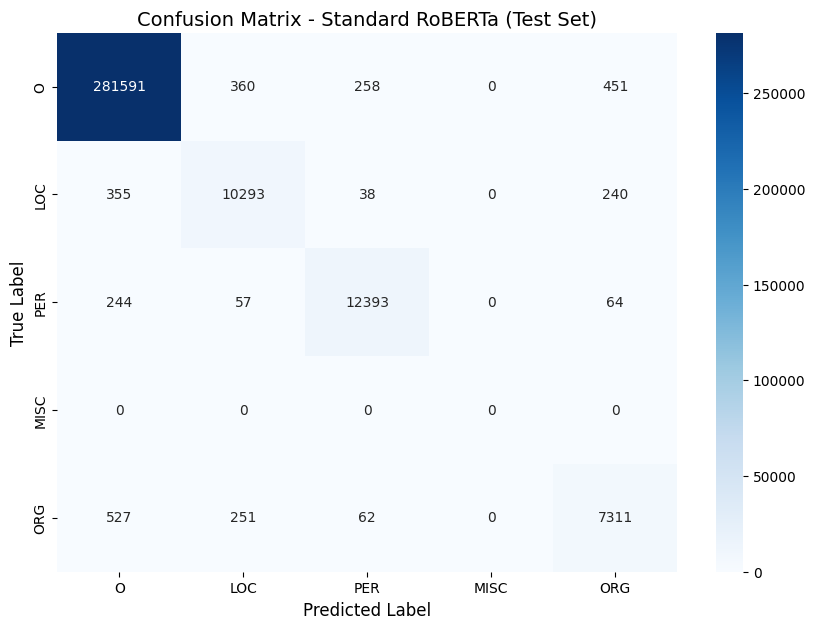


Mengekstrak metrik Training vs Testing...


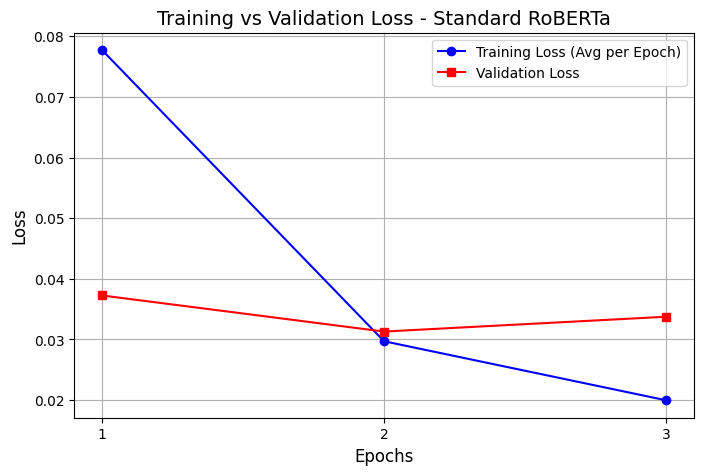

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd

# ==========================================
# 1. GENERATE CONFUSION MATRIX
# ==========================================
print("Membuat Confusion Matrix...")
# Ambil hasil prediksi dari test set
predictions_output = trainer.predict(tokenized_dataset["test"])
preds = np.argmax(predictions_output.predictions, axis=-1)
label_ids = predictions_output.label_ids

flat_true, flat_preds = [], []
for pred_seq, label_seq in zip(preds, label_ids):
    for p, l in zip(pred_seq, label_seq):
        if l != -100: # Abaikan token -100
            flat_true.append(ID2LABEL[l])
            flat_preds.append(ID2LABEL[p])

# Plotting
cm = confusion_matrix(flat_true, flat_preds, labels=LABEL_LIST)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_LIST, yticklabels=LABEL_LIST)
plt.title('Confusion Matrix - Standard RoBERTa (Test Set)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# ==========================================
# 2. PERBANDINGAN TRAINING VS TESTING LOSS (DIPERBAIKI)
# ==========================================
print("\nMengekstrak metrik Training vs Testing...")
log_history = trainer.state.log_history

train_loss_dict = {}
eval_loss_dict = {}

# Ekstraksi log secara presisi berdasarkan letak epoch
for log in log_history:
    # Ambil nilai epoch, abaikan log yang tidak memiliki key epoch
    if 'epoch' not in log:
        continue

    ep = log['epoch']

    # Kelompokkan training loss berdasarkan epoch (dibulatkan ke atas untuk rata-rata per ronde)
    if 'loss' in log:
        epoch_idx = int(np.ceil(ep))
        if epoch_idx <= EPOCHS:
            if epoch_idx not in train_loss_dict:
                train_loss_dict[epoch_idx] = []
            train_loss_dict[epoch_idx].append(log['loss'])

    # Ambil evaluation loss yang nilainya bilangan bulat (akhir epoch)
    if 'eval_loss' in log:
        # Menghindari masuknya log eval dari test set
        if ep.is_integer() and ep <= EPOCHS:
            eval_loss_dict[int(ep)] = log['eval_loss']

# Hitung rata-rata training loss per epoch agar sejajar dengan eval loss
train_loss_clean = [np.mean(train_loss_dict[i]) for i in range(1, EPOCHS + 1) if i in train_loss_dict]
eval_loss_clean = [eval_loss_dict[i] for i in range(1, EPOCHS + 1) if i in eval_loss_dict]
clean_epochs = range(1, len(eval_loss_clean) + 1)

# Plot Kurva Loss yang Rasional
plt.figure(figsize=(8, 5))
plt.plot(clean_epochs, train_loss_clean, 'b-', label='Training Loss (Avg per Epoch)', marker='o')
plt.plot(clean_epochs, eval_loss_clean, 'r-', label='Validation Loss', marker='s')

plt.title('Training vs Validation Loss - Standard RoBERTa', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(clean_epochs) # Memaksa sumbu X hanya menampilkan angka integer (1, 2, 3)
plt.legend()
plt.grid(True)
plt.show()